# Relative Approximation Ratio across 5 Initialization Strategies -- EXACT

**Exact (analytic, statevector, `shots=None`) counterpart of the Monte-Carlo `Ratio_5_Initializations.ipynb`.**

Identical to the MC version in *logic* -- same initializations, same ratio
definitions, same optimizer settings (Adam, `stepsize=1e-3`, `n_iters=1000`,
50 instances, qubits 3..18). The ONLY change is the engine:

| | MC version (`Ratio_5_Initializations`) | This notebook |
|---|---|---|
| Engine | IQPopt `IqpSimulator` | PennyLane `lightning.qubit` |
| Expectation | `op_expval(..., n_samples=1000)` (sampling) | exact statevector `shots=None` |
| Circuit | `gens` / `iqp` (IQPopt) | `iqp_layer` (`IQP_circuit_pennylane`) |

Using PennyLane exact here makes this figure **consistent with `GV_5_Initializations`**
(also PennyLane exact), removing the MC-vs-exact / two-engine mismatch.

> IQPopt's `op_expval` has no exact mode (it is a sampling estimator by construction),
> so "MC -> exact" cannot be a flag flip inside IQPopt -- hence the engine switch.

In [1]:
import json
import numpy as np
import pennylane as qp
from pennylane import numpy as qnp
import matplotlib.pyplot as plt

# Circuit + Hamiltonian builders (PennyLane, exact)
from IQP_circuit_pennylane import iqp_layer, binary_ops_to_hamiltonian
from IQP_circuit import maxcut_obs, number_partition_obs   # binary-op builders
from MaxCut import maxcut_value, solve_maxcut_exact_symmetry
from Partition import sum_selected
from numberpartitioning import karmarkar_karp

## Initialization sampler (identical to the MC version) + helpers

In [2]:
PI4_EPS = 0.05  # half-width of the near-pi/4 window

def init_params(name, n_gates, n_qubits):
    if name == 'normal':
        return np.random.normal(0.0, 1.0, n_gates)
    if name == 'uniform':
        return np.random.uniform(-np.pi, np.pi, n_gates)
    if name == 'pi4':
        return np.random.uniform(np.pi/4 - PI4_EPS, np.pi/4 + PI4_EPS, n_gates)
    if name == 'he':
        return np.random.normal(0.0, np.sqrt(2.0 / n_qubits), n_gates)
    if name == 'glorot':
        return np.random.normal(0.0, np.sqrt(1.0 / n_qubits), n_gates)
    raise ValueError(f"Unknown init '{name}'")

# Flat parameter-vector length; matches len(gens(n, mode)) of the MC version.
def n_gates_for(mode_circuit, n_qubits):
    if mode_circuit == 'single':   return n_qubits
    if mode_circuit == 'circular': return 2 * n_qubits
    if mode_circuit == 'full':     return n_qubits + n_qubits * (n_qubits - 1) // 2
    raise ValueError(f"Unknown mode '{mode_circuit}'")

def ising_obs_local(n_qubits, corr=2):
    obs = []
    for i in range(n_qubits):
        v = [0] * n_qubits; v[i] = 1; obs.append(v)
    if corr == 2:
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                v = [0] * n_qubits; v[i] = 1; v[j] = 1; obs.append(v)
    return np.array(obs)

## Load datasets (same files as the MC version)

In [3]:
with open("ising.json", "r") as f:
    dataset_ising = {int(k): v for k, v in json.load(f).items()}
with open("ising_loss_exact.json", "r") as f:
    exact_ising = {int(k): v for k, v in json.load(f).items()}
with open("maxcut.json", "r") as f:
    dataset_maxcut = {int(k): v for k, v in json.load(f).items()}
with open("partition.json", "r") as f:
    dataset_partition = {int(k): v for k, v in json.load(f).items()}

print("Datasets loaded successfully")

Datasets loaded successfully


## Exact optimization core (PennyLane statevector)

Same optimizer settings as the MC version. The parameter vector is flat
(length `n_gates_for(mode, n)`) and split into single-qubit / pairwise angles
inside the circuit, so `init_params` is reused unchanged.

In [4]:
N_ITERS  = 1000     # optimization steps (Adam)
STEPSIZE = 1e-3

def _expval_flat(params, H, n_qubits, mode_circuit):
    iqp_layer(params[:n_qubits], params[n_qubits:], mode_circuit)
    return qp.expval(H)

def _probs_flat(params, n_qubits, mode_circuit):
    iqp_layer(params[:n_qubits], params[n_qubits:], mode_circuit)
    return qp.probs(wires=range(n_qubits))

def train_exact(H, n_qubits, mode_circuit, params_init, n_iters=N_ITERS, stepsize=STEPSIZE):
    dev   = qp.device("lightning.qubit", wires=n_qubits, shots=None)
    qnode = qp.QNode(_expval_flat, dev, interface="autograd")
    params = qnp.array(params_init, requires_grad=True)
    opt = qp.AdamOptimizer(stepsize)
    cost = lambda p: qnode(p, H, n_qubits, mode_circuit)
    for _ in range(n_iters):
        params = opt.step(cost, params)
    return params, float(cost(params))

def get_probs(params, n_qubits, mode_circuit):
    dev   = qp.device("lightning.qubit", wires=n_qubits, shots=None)
    qnode = qp.QNode(_probs_flat, dev, interface="autograd")
    return np.array(qnode(qnp.array(params, requires_grad=False), n_qubits, mode_circuit))

## Ratio functions (identical definitions to the MC version; only loss/probs are now exact)

In [5]:
def ratio_ising(n, j, init, mode_circuit):
    coeffs = np.array(dataset_ising[n][j])
    ops = ising_obs_local(n, 2)
    H = binary_ops_to_hamiltonian(ops, coeffs)
    p0 = init_params(init, n_gates_for(mode_circuit, n), n)
    _, final_loss = train_exact(H, n, mode_circuit, p0)
    return float((exact_ising[n][j] - final_loss) / exact_ising[n][j])

def ratio_maxcut(n, j, init, mode_circuit):
    edges, weights = dataset_maxcut[n][j]
    ops, coeffs = maxcut_obs(n, edges, weights)
    H = binary_ops_to_hamiltonian(ops, coeffs)
    p0 = init_params(init, n_gates_for(mode_circuit, n), n)
    params, _ = train_exact(H, n, mode_circuit, p0)
    probs = get_probs(params, n, mode_circuit)
    bits = np.binary_repr(int(np.argmax(probs)), n)
    sol = maxcut_value(bits, edges, weights)
    ex = solve_maxcut_exact_symmetry(edges, weights)[0]
    return float(abs(sol - ex) / ex)

def ratio_partition(n, j, init, mode_circuit):
    numbers = dataset_partition[n][j]
    ops, coeffs = number_partition_obs(numbers)
    H = binary_ops_to_hamiltonian(ops, coeffs)
    p0 = init_params(init, n_gates_for(mode_circuit, n), n)
    params, _ = train_exact(H, n, mode_circuit, p0)
    probs = get_probs(params, n, mode_circuit)
    bits = np.binary_repr(int(np.argmax(probs)), n)
    sol = sum_selected(bits, numbers)
    ex = karmarkar_karp(numbers, num_parts=2)
    denom = sum(ex.partition[0])
    return float(abs(sol - denom) / denom)

ratio_fns = {'ising': ratio_ising, 'maxcut': ratio_maxcut, 'partition': ratio_partition}

## Compute the exact ratio for all 5 initializations

**Warning -- compute cost.** Exact statevector training scales as `2**n`; the heavy
corner is `full` connectivity at `n=18` (statevector 2^18, ~171 params, 1000 Adam
steps, 50 instances). Consider a reduced sweep first (e.g. `qubits=[3,6,9]`,
`n_problem=10`) to sanity-check against the MC figure before the full run.

In [6]:
np.random.seed(42)   # reproducible initial parameters (exact run)

inits             = ['normal', 'uniform', 'pi4', 'he', 'glorot']
mode_hamiltonians = ['ising', 'maxcut', 'partition']
mode_circuits     = ['single', 'circular', 'full']
qubits            = [3, 6, 9, 12, 15]
n_problem         = 50

all_results = {}

for init_name in inits:
    print(f"\n{'='*40}\nInit: {init_name}")
    results = {}
    for mode_ham in mode_hamiltonians:
        print(f"  === {mode_ham} ===")
        results[mode_ham] = {}
        rfn = ratio_fns[mode_ham]
        for mode_circuit in mode_circuits:
            print(f"    {mode_circuit}")
            results[mode_ham][mode_circuit] = {}
            for n_qubits in qubits:
                print(f"      n={n_qubits}", end=" ... ", flush=True)
                ratios = [rfn(n_qubits, j, init_name, mode_circuit)
                          for j in range(n_problem)]
                results[mode_ham][mode_circuit][n_qubits] = ratios
                print(f"mean={np.mean(ratios):.3f}")
    all_results[init_name] = results

with open("ratio_5inits_exact.json", "w") as f:
    json.dump(all_results, f, indent=4)
print("\nSaved to ratio_5inits_exact.json")


Init: normal
  === ising ===
    single
      n=3 ... mean=0.825
      n=6 ... mean=0.849
      n=9 ... mean=0.841
      n=12 ... mean=0.818
      n=15 ... mean=0.878
    circular
      n=3 ... mean=0.493
      n=6 ... mean=0.584
      n=9 ... mean=0.617
      n=12 ... mean=0.597
      n=15 ... mean=0.685
    full
      n=3 ... mean=0.484
      n=6 ... mean=0.461
      n=9 ... mean=0.548
      n=12 ... mean=0.642
      n=15 ... mean=0.704
  === maxcut ===
    single
      n=3 ... mean=0.177
      n=6 ... mean=0.217
      n=9 ... mean=0.266
      n=12 ... mean=0.237
      n=15 ... mean=0.240
    circular
      n=3 ... mean=0.023
      n=6 ... mean=0.114
      n=9 ... mean=0.129
      n=12 ... mean=0.126
      n=15 ... mean=0.133
    full
      n=3 ... mean=0.012
      n=6 ... mean=0.049
      n=9 ... mean=0.106
      n=12 ... mean=0.146
      n=15 ... mean=0.170
  === partition ===
    single
      n=3 ... mean=0.208
      n=6 ... mean=0.242
      n=9 ... mean=0.229
      n=12 ... mean

## Plot (same 3x5 layout as the MC version)

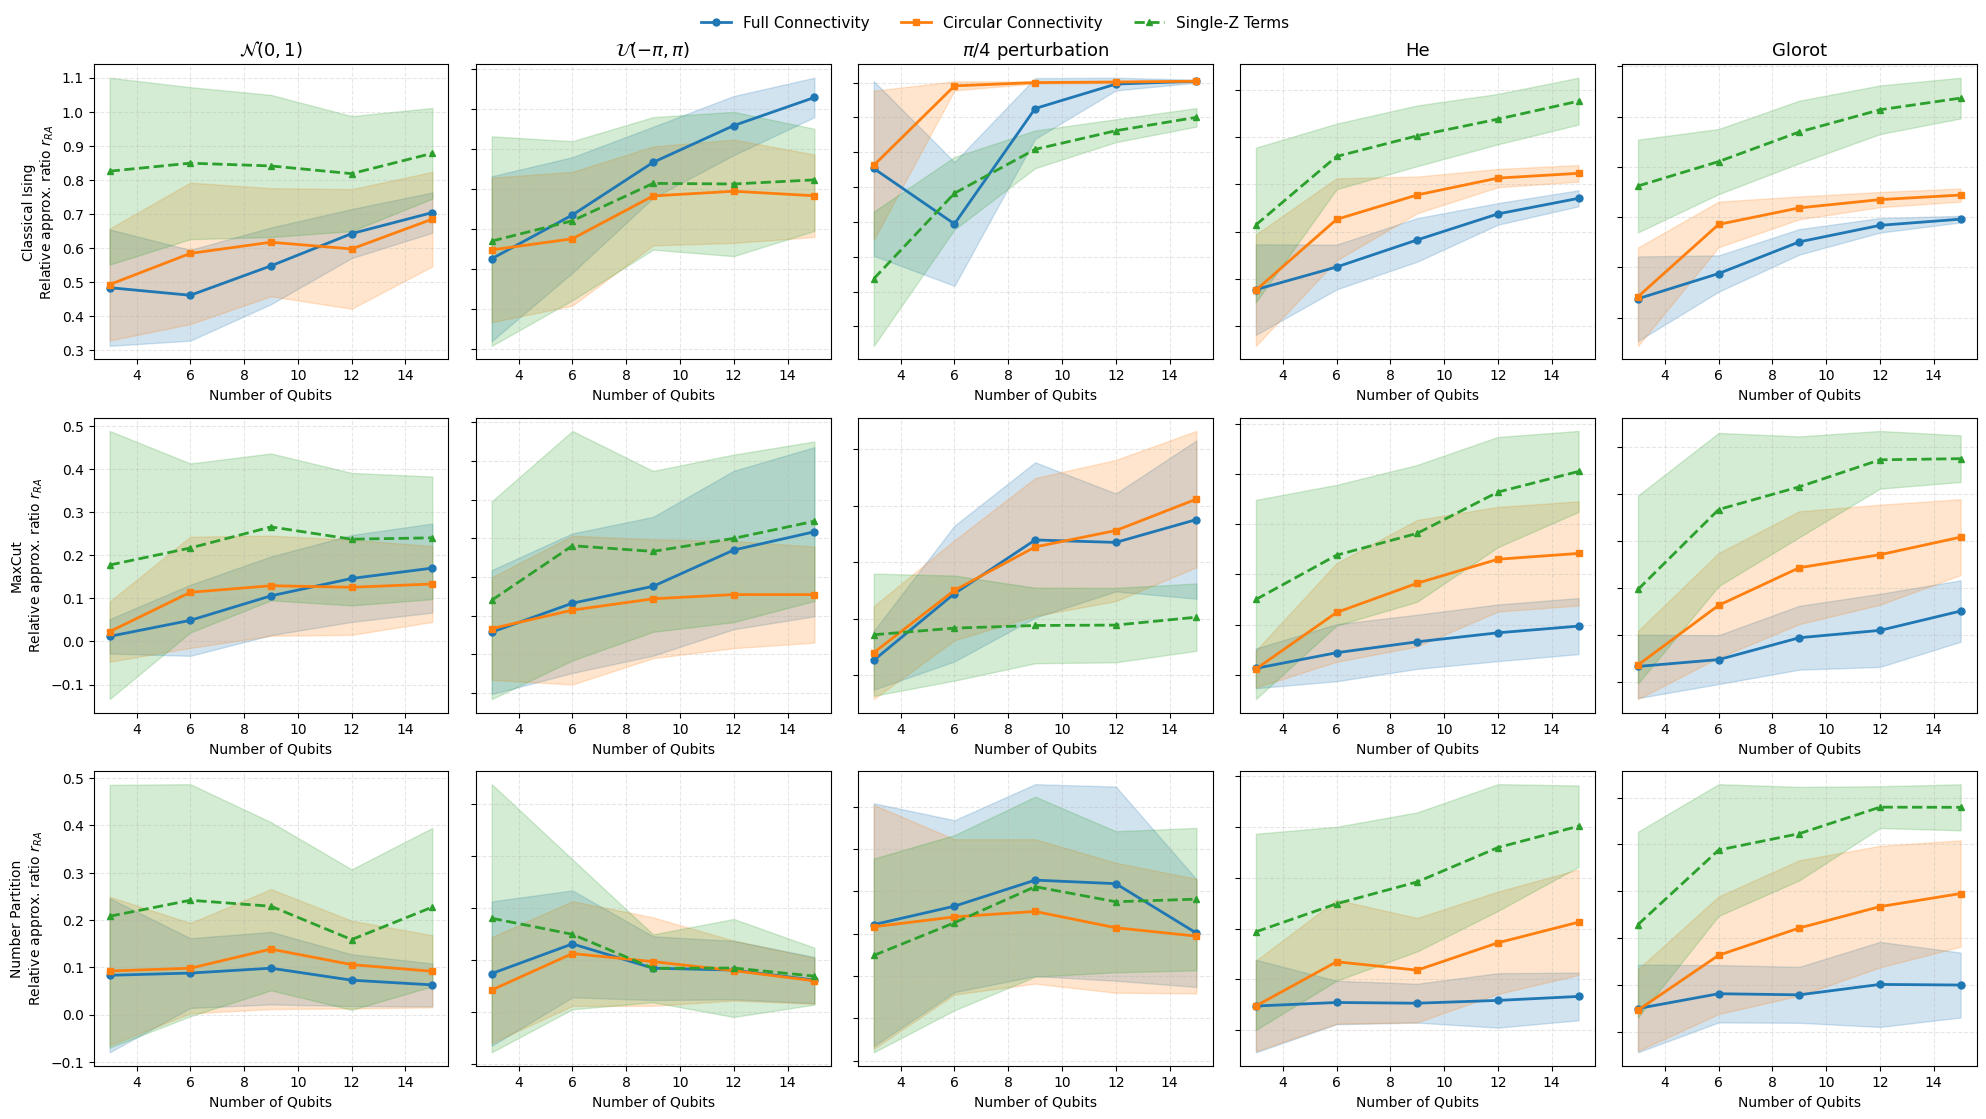

In [10]:
with open("ratio_5inits_exact.json", "r") as f:
    all_results = json.load(f)

qubits = [3, 6, 9, 12, 15]

ham_names = {'ising': 'Classical Ising', 'maxcut': 'MaxCut', 'partition': 'Number Partition'}
styles = {'full': ('o-', '#1f77b4'), 'circular': ('s-', '#ff7f0e'), 'single': ('^--', '#2ca02c')}
labels = {'full': 'Full Connectivity', 'circular': 'Circular Connectivity', 'single': 'Single-Z Terms'}

init_cols  = ['normal', 'uniform', 'pi4', 'he', 'glorot']
col_titles = {
    'normal':  r'$\mathcal{N}(0, 1)$',
    'uniform': r'$\mathcal{U}(-\pi, \pi)$',
    'pi4':     r'$\pi/4$ perturbation',
    'he':      'He',
    'glorot':  'Glorot',
}
row_ylim = {0: (0.0, 1.0), 1: (0.0, 0.6), 2: (0.0, 0.4)}

fig, axes = plt.subplots(3, 5, figsize=(20, 11))

for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax  = axes[row][col]
        res = all_results[init_name][mode_ham]

        for mode_circuit in ['full', 'circular', 'single']:
            means = np.array([np.mean(res[mode_circuit][str(n)]) for n in qubits])
            stds  = np.array([np.std(res[mode_circuit][str(n)])  for n in qubits])
            fmt, color = styles[mode_circuit]
            ax.plot(qubits, means, fmt, color=color, label=labels[mode_circuit],
                    linewidth=2, markersize=5)
            ax.fill_between(qubits, means - stds, means + stds, color=color, alpha=0.2)

        #ax.set_ylim(*row_ylim[row])
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')
        if col == 0:
            ax.set_ylabel(f'{ham_names[mode_ham]}\n'
                          r'Relative approx. ratio $r_{RA}$', fontsize=10)
        else:
            ax.set_yticklabels([])
        if row == 0:
            ax.set_title(col_titles[init_name], fontsize=13)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("Ratio_5_initializations_exact.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# TEST: He init tren IQP -- landscape kho (a) hay undertraining (b)?
# Chay SAU cac cell: init_params, n_gates_for, ising_obs_local,
#                    binary_ops_to_hamiltonian, _expval_flat, dataset_ising, exact_ising
# ============================================================

def _cost_qnode(H, n_qubits, mode_circuit):
    dev = qp.device("lightning.qubit", wires=n_qubits, shots=None)
    qnode = qp.QNode(_expval_flat, dev, interface="autograd")
    return lambda p: qnode(p, H, n_qubits, mode_circuit)

def train_with_history(H, n_qubits, mode_circuit, params_init, n_iters, stepsize, rec=50):
    """Train va tra ve quy dao loss de xem da hoi tu (plateau) hay con giam."""
    cost = _cost_qnode(H, n_qubits, mode_circuit)
    params = qnp.array(params_init, requires_grad=True)
    opt = qp.AdamOptimizer(stepsize)
    hist = [(0, float(cost(params)))]
    for it in range(1, n_iters + 1):
        params = opt.step(cost, params)
        if it % rec == 0 or it == n_iters:
            hist.append((it, float(cost(params))))
    return params, hist

def r_ra_ising(loss, n, j):
    ex = exact_ising[n][j]
    return abs((ex - loss) / ex)

# ---- cau hinh soi (doi thoai mai) ----
mode_circuit = 'full'
init_name    = 'he'        # doi 'glorot' / 'normal' de doi chieu
j            = 0           # instance index
n_list       = [6, 12]     # them 15 neu chiu duoc chi phi (2^15 x 5000 buoc)

np.random.seed(0)
print(f"Config: Ising | {mode_circuit} | init={init_name} | instance j={j}")
print(f"{'n':>3} {'setting':>18} {'loss_init':>11} {'loss_fin':>11} "
      f"{'rRA_init':>9} {'rRA_fin':>9} {'tail%':>9}")

for n in n_list:
    coeffs = np.array(dataset_ising[n][j])
    ops = ising_obs_local(n, 2)
    H = binary_ops_to_hamiltonian(ops, coeffs)
    p0 = init_params(init_name, n_gates_for(mode_circuit, n), n)   # cung 1 p0 cho ca 3 setting

    for tag, iters, lr in [("baseline 1000/1e-3", 1000, 1e-3),
                           ("more     5000/1e-3", 5000, 1e-3),
                           ("hi-lr    1000/1e-2", 1000, 1e-2)]:
        _, hist = train_with_history(H, n, mode_circuit, p0, iters, lr)
        loss_init, loss_fin = hist[0][1], hist[-1][1]
        # tail%: % thay doi loss trong ~10% buoc cuoi (am = con dang giam)
        k = max(1, len(hist) // 10)
        tail = 100.0 * (hist[-1][1] - hist[-1 - k][1]) / (abs(hist[-1][1]) + 1e-12)
        print(f"{n:>3} {tag:>18} {loss_init:11.4f} {loss_fin:11.4f} "
              f"{r_ra_ising(loss_init, n, j):9.3f} {r_ra_ising(loss_fin, n, j):9.3f} {tail:9.2f}")
    print()



Config: Ising | full | init=he | instance j=0
  n            setting   loss_init    loss_fin  rRA_init   rRA_fin     tail%
  6 baseline 1000/1e-3      1.7308     -1.5806     1.436     0.602    -12.38
  6 more     5000/1e-3      1.7308     -2.9573     1.436     0.256     -0.00
  6 hi-lr    1000/1e-2      1.7308     -2.9573     1.436     0.256     -0.00

 12 baseline 1000/1e-3      5.2027     -1.6252     1.445     0.861    -26.62
 12 more     5000/1e-3      5.2027     -8.2198     1.445     0.297      0.00
 12 hi-lr    1000/1e-2      5.2027     -6.4572     1.445     0.447      0.00

